# Comparative Analysis of Supervised Classification: Titanic Survival Prediction
**Author:** Oleksii Ishchenko  
**Track:** Machine Learning & MLOps — Week 1  

---

## 1. Introduction

This notebook establishes the research and implementation framework for the first part of the Week 1 assignment within the Machine Learning and MLOps track. The objective of this study is to evaluate the predictive capabilities of supervised machine learning algorithms when applied to historical survival data.

Supervised learning functions by processing training samples where both the input variables (features) and the true ground-truth outputs (labels) are known, optimizing model parameters to map patterns within the feature space. Because the target metric—passenger survival—is categorical, this task is structured as a binary classification problem.

The scope of this initial notebook is strictly focused on the primary phase of the assignment:

* **Exploration:** Becoming familiar with the structure and content of the dataset. Inspecting the data to create summaries, identifying data types, checking for data quality issues, and creating visualizations.
* **Model Training:** Using the prepared dataset to train a classification model (logistic regression) using the `scikit-learn` library.
* **Evaluation:** Evaluating the performance of the model by exploring multiple evaluation metrics and reflecting on what each reveals about the model.

The dataset analyzed throughout this research is located within the verified path: `../../description/mlops/week-1/data/titanic.csv`.

## Load and Inspect the Dataset

In [4]:
import pandas as pd
import numpy as np

## Path to the data in my configuration
df = pd.read_csv("titanic.csv")

print("=== 1. CSV DATA GIVEN IN THE TITANIC DATASET ===")
print(df.info())

print("\n=== 2. ANALYSIS OF THE NUMERIC DATA ON BEING NULL/NOT GIVEN ===")
print(df.isna().sum())

=== 1. CSV DATA GIVEN IN THE TITANIC DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB
None

=== 2. ANALYSIS OF THE NUMERIC DATA ON BEING NULL/NOT GIVEN ===
sex            0
age            0
family_size    0
fare           0
1st_class      0
2nd_class      0
3rd_class      0
survived       0
dtype: int64


In [5]:
print("=== 3. SEMANTIC RANGE AUDIT FOR CONTINUOUS DATA===")
print(df[["age", "family_size", "fare"]].describe())

=== 3. SEMANTIC RANGE AUDIT FOR CONTINUOUS DATA===
              age  family_size       fare
count  887.000000   887.000000  887.00000
mean    29.471443     0.908681   32.30542
std     14.121908     1.615949   49.78204
min      0.420000     0.000000    0.00000
25%     20.250000     0.000000    7.92500
50%     28.000000     0.000000   14.45420
75%     38.000000     1.000000   31.13750
max     80.000000    10.000000  512.32920


#### 2.1 Data Dictionary & Target Variable Mapping
To perform a rigorous data quality check, we analyze the semantic meaning of the encoded features. The binary classifications within the feature space are defined as follows:

| Feature Variable | Original Encoding | Semantic Text Label | Description |
| :--- | :--- | :--- | :--- |
| **sex** | `0`<br>`1` | Female<br>Male | The biological sex of the passenger. |
| **survived** | `0`<br>`1` | Perished<br>Survived | The ground-truth target classification label. |
| **1st_class** | `0` or `1` | *Unchanged* | Indicator variable for upper-tier socio-economic booking status. |
| **2nd_class** | `0` or `1` | *Unchanged* | Indicator variable for middle-tier socio-economic booking status. |
| **3rd_class** | `0` or `1` | *Unchanged* | Indicator variable for lower-tier socio-economic booking status. |

In [6]:
audit_df = df.copy()
    
    # Map raw binary states to explicit semantic labels for data profiling
audit_df['sex'] = audit_df['sex'].map({0: 'female', 1: 'male'})
audit_df['survived'] = audit_df['survived'].map({0: 'perished', 1: 'survived'})

print("=== Data Consistency Audit: Categorical Distributions ===")
print("\n--- Sex Feature Value Distribution ---")
print(audit_df['sex'].value_counts(dropna=False))

print("\n--- Survived Target Value Distribution ---")
print(audit_df['survived'].value_counts(dropna=False))

print("\n\n=== Sample Record Verification (First 5 Rows) ===")
print(audit_df[['sex', 'age', '1st_class', '2nd_class', '3rd_class', 'survived']].head())

=== Data Consistency Audit: Categorical Distributions ===

--- Sex Feature Value Distribution ---
sex
male      573
female    314
Name: count, dtype: int64

--- Survived Target Value Distribution ---
survived
perished    545
survived    342
Name: count, dtype: int64


=== Sample Record Verification (First 5 Rows) ===
      sex   age  1st_class  2nd_class  3rd_class  survived
0    male  22.0          0          0          1  perished
1  female  38.0          1          0          0  survived
2  female  26.0          0          0          1  survived
3  female  35.0          1          0          0  survived
4    male  35.0          0          0          1  perished


### 2.2 Exploratory Data Analysis (EDA) & High-Fidelity Visualizations

To understand the underlying patterns within the Titanic passenger cohort, we must execute a series of targeted data visualizations. This analysis is designed to move from global baseline distributions down to multi-variable interactions.

We begin by mapping two foundational univariate metrics:
1. **The Target Variable Class Balance:** Evaluating the absolute counts of individuals who perished vs. survived to understand our model's classification target distribution.
2. **The Age Dispersion Profile:** Analyzing the continuous density distribution of passenger ages to observe demographics, sample variance, and potential skewness.

=== Target and Percentage Age Distribution Exported ===


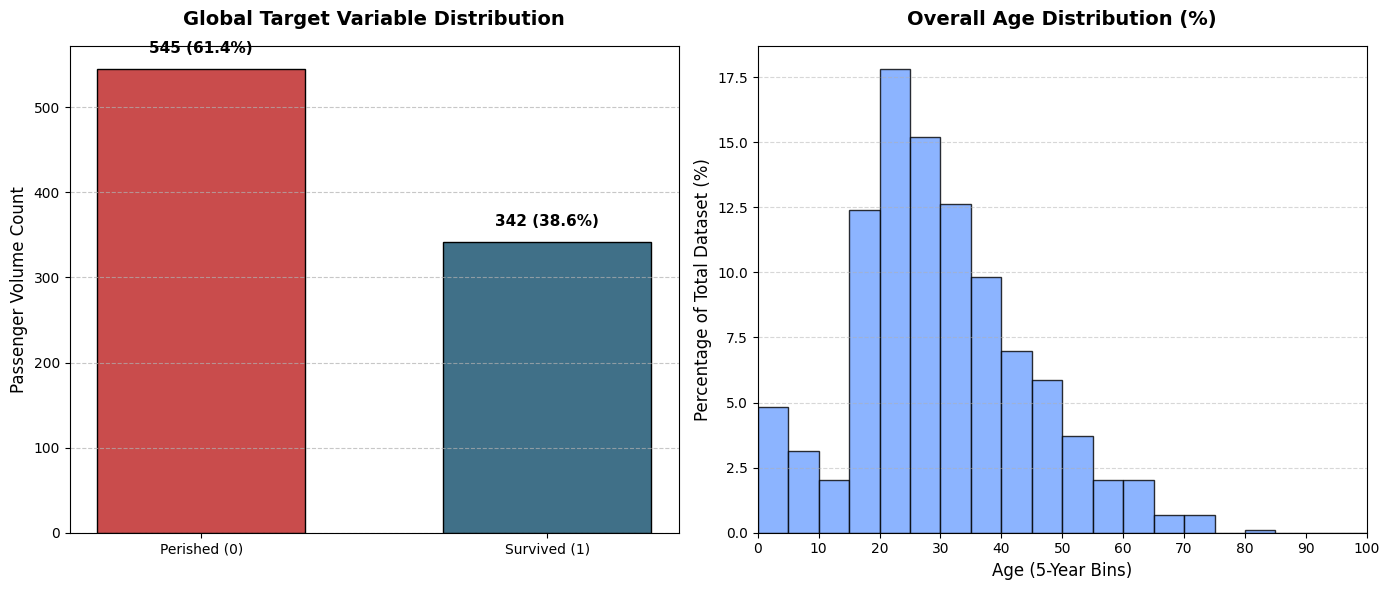

In [7]:
import matplotlib.pyplot as plt

plt.savefig("../diagrams")

fig, ax = plt.subplots(ncols=2, figsize=(14, 6))
survival_counts = df['survived'].value_counts().sort_index()
labels = ['Perished (0)', 'Survived (1)']
colors = ['#c94c4c', '#407088']

ax[0].bar(labels, survival_counts, color=colors, edgecolor='black', width=0.6)
ax[0].set_title("Global Target Variable Distribution", fontsize=14, fontweight='bold', pad=15)
ax[0].set_ylabel("Passenger Volume Count", fontsize=12)
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Append raw value labels on top of the bars for exact precision
for i, count in enumerate(survival_counts):
    ax[0].text(i, count + 15, f"{count} ({count/len(df)*100:.1f}%)", ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Plot 2: Age Dispersion Profile ---
# Utilizing a histogram with a Kernel Density Estimate tracking representation
bins = np.linspace(0, 100, 21) # 20 columns, 5 years each
weights = np.ones_like(df['age']) * 100.0 / len(df) # Convert to %

ax[1].hist(df['age'], bins=bins, weights=weights, color='#70a1ff', edgecolor='black', alpha=0.8)
ax[1].set_title("Overall Age Distribution (%)", fontsize=14, fontweight='bold', pad=15)
ax[1].set_xlabel("Age (5-Year Bins)", fontsize=12)
ax[1].set_ylabel("Percentage of Total Dataset (%)", fontsize=12)
ax[1].set_xlim(0, 100)
ax[1].set_xticks(np.arange(0, 101, 10))
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

# Format and save
plt.tight_layout()
fig.savefig("baseline_target_and_percentage_age.png", dpi=300)
print("=== Target and Percentage Age Distribution Exported ===")

### 2.3 Normalized Demographics: Male vs. Female Age Distribution

To uncover structural demographic variations between genders, the passenger data is isolated into Male and Female cohorts. 

The age spectrum (0 to 100 years) is divided into 20 distinct intervals. The Y-axis is mathematically scaled using fractional weights to represent the exact percentage of the population that falls within each cohort, relative to that specific gender's total volume. The Y-axis is shared across both distributions to prevent visual bias and maintain a 1:1 comparative scale.

=== Gender Age Demographics Exported Successfully ===


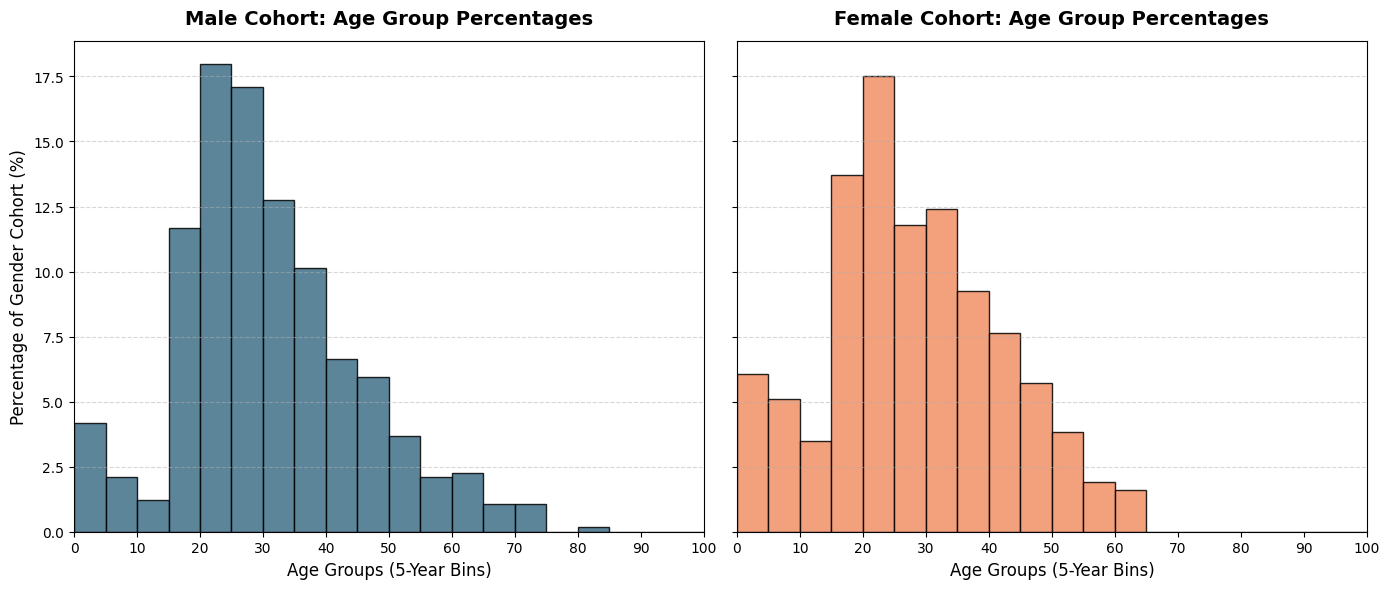

In [8]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 6), sharey=True)

# Establish the 20 distinct columns from 0 to 100 years
bins = np.linspace(0, 100, 21)

# Isolate the gender groups
male_ages = df[df['sex'] == 1]['age']
female_ages = df[df['sex'] == 0]['age']

# Create weight vectors to convert raw counts into percentages (adding up to 100% per gender)
male_weights = np.ones_like(male_ages) * 100.0 / len(male_ages)
female_weights = np.ones_like(female_ages) * 100.0 / len(female_ages)

# --- LEFT PAPER (ax[0]): Male Demographics ---
ax[0].hist(male_ages, bins=bins, weights=male_weights, color='#407088', edgecolor='black', alpha=0.85)
ax[0].set_title("Male Cohort: Age Group Percentages", fontsize=14, fontweight='bold', pad=12)
ax[0].set_xlabel("Age Groups (5-Year Bins)", fontsize=12)
ax[0].set_ylabel("Percentage of Gender Cohort (%)", fontsize=12)
ax[0].set_xlim(0, 100)
ax[0].set_xticks(np.arange(0, 101, 10))
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- RIGHT PAPER (ax[1]): Female Demographics ---
ax[1].hist(female_ages, bins=bins, weights=female_weights, color='#f19066', edgecolor='black', alpha=0.85)
ax[1].set_title("Female Cohort: Age Group Percentages", fontsize=14, fontweight='bold', pad=12)
ax[1].set_xlabel("Age Groups (5-Year Bins)", fontsize=12)
# No need to set ylabel here because sharey=True perfectly mirrors the left axis
ax[1].set_xlim(0, 100)
ax[1].set_xticks(np.arange(0, 101, 10))
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

# Format and save to disk
plt.tight_layout()
fig.savefig("gender_percentage_age_distribution.png", dpi=300)
print("=== Gender Age Demographics Exported Successfully ===")

### 2.4 Multivariate Demographics: Survival Stratification by Age and Gender

To evaluate the correlation between age, gender, and survivability, the previous demographic distributions are sub-divided by the target variable. 

Each 5-year age interval is split into a stacked column representing the proportion of passengers who perished (Red) versus those who survived (Green). The Y-axis remains locked to the relative percentage of the total gender cohort, allowing us to observe both the volume of the age group and its internal survival rate simultaneously.

=== Stacked Multivariate Survival Demographics Exported ===


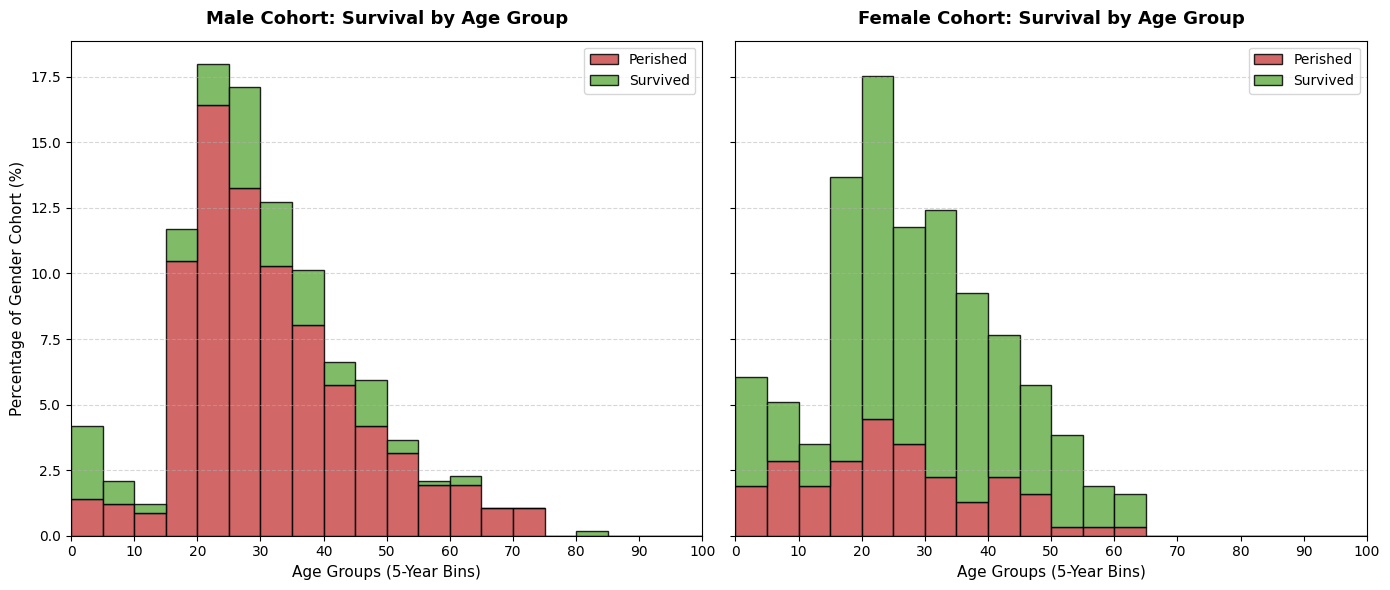

In [9]:
bins = np.linspace(0, 100, 21)

# Isolate the gender groups (The Dataframes)
male_df = df[df['sex'] == 1]
female_df = df[df['sex'] == 0]

# Split each gender into Survived (1) and Perished (0) age arrays
male_died = male_df[male_df['survived'] == 0]['age']
male_survived = male_df[male_df['survived'] == 1]['age']

female_died = female_df[female_df['survived'] == 0]['age']
female_survived = female_df[female_df['survived'] == 1]['age']

# Compute weight vectors (relative to the TOTAL gender population)
mw_died = np.ones_like(male_died) * 100.0 / len(male_df)
mw_surv = np.ones_like(male_survived) * 100.0 / len(male_df)

fw_died = np.ones_like(female_died) * 100.0 / len(female_df)
fw_surv = np.ones_like(female_survived) * 100.0 / len(female_df)

# Initialize the multi-panel shared Y-axis canvas
fig, ax = plt.subplots(ncols=2, figsize=(14, 6), sharey=True)

# Define the thematic colors (Red for Perished, Green for Survived)
colors = ['#c94c4c', '#6ab04c']
labels = ['Perished', 'Survived']

# --- Panel 1: Male Stacked Survival ---
# Notice we pass a LIST of arrays [died, survived] and stacked=True
ax[0].hist([male_died, male_survived], bins=bins, weights=[mw_died, mw_surv], 
           stacked=True, color=colors, edgecolor='black', alpha=0.85, label=labels)
ax[0].set_title("Male Cohort: Survival by Age Group", fontsize=13, fontweight='bold', pad=12)
ax[0].set_xlabel("Age Groups (5-Year Bins)", fontsize=11)
ax[0].set_ylabel("Percentage of Gender Cohort (%)", fontsize=11)
ax[0].set_xlim(0, 100)
ax[0].set_xticks(np.arange(0, 101, 10))
ax[0].legend(loc='upper right')
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Panel 2: Female Stacked Survival ---
ax[1].hist([female_died, female_survived], bins=bins, weights=[fw_died, fw_surv], 
           stacked=True, color=colors, edgecolor='black', alpha=0.85, label=labels)
ax[1].set_title("Female Cohort: Survival by Age Group", fontsize=13, fontweight='bold', pad=12)
ax[1].set_xlabel("Age Groups (5-Year Bins)", fontsize=11)
ax[1].set_xlim(0, 100)
ax[1].set_xticks(np.arange(0, 101, 10))
ax[1].legend(loc='upper right')
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

# Optimize spatial geometry to prevent edge truncation
plt.tight_layout()

# Export the high-fidelity visualization artifact directly to storage
fig.savefig("stacked_gender_survival_distribution.png", dpi=300)
print("=== Stacked Multivariate Survival Demographics Exported ===")

### 2.5 Socio-Economic Stratification: Survival by Ticket Class and Gender

To evaluate the impact of socio-economic status on survivability, we analyze the distribution of passengers across the three ticket classes. 

Because the original dataset utilizes One-Hot Encoding for the ticket tiers (`1st_class`, `2nd_class`, `3rd_class`), we systematically condense these into a unified categorical feature space. The resulting stacked bar chart visualizes the absolute percentage of the respective gender cohort that occupied each class, subdivided by their survival outcome (Perished vs. Survived).

=== Ticket Class Demographics Rendered and Exported Successfully ===


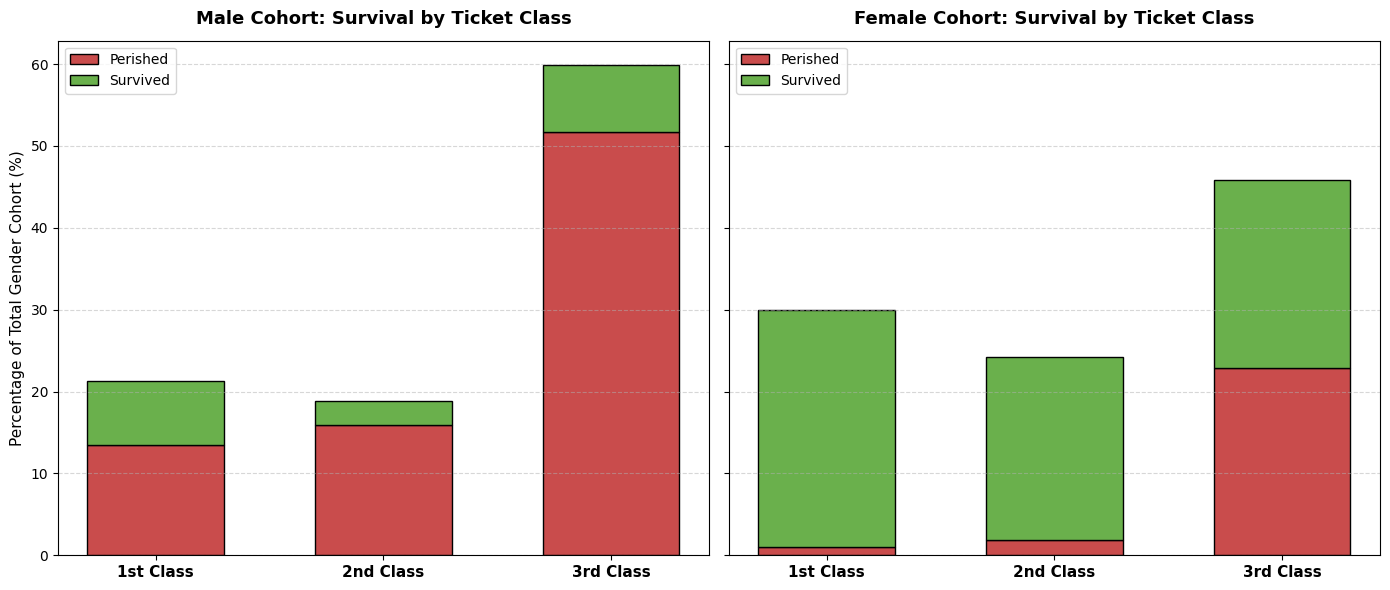

In [10]:
df['ticket_class'] = np.where(df['1st_class'] == 1, '1st Class', 
                       np.where(df['2nd_class'] == 1, '2nd Class', '3rd Class'))

#  Isolate the gender DataFrames
male_df = df[df['sex'] == 1]
female_df = df[df['sex'] == 0]

def calculate_class_percentages(gender_df):
    """
    Groups the dataframe by ticket class and survival, counts the individuals, 
    and converts them into a percentage relative to the total gender population.
    """
    total_population = len(gender_df)
    
    # Create a matrix of counts: rows = ticket_class, columns = survived (0 or 1)
    counts = gender_df.groupby(['ticket_class', 'survived']).size().unstack(fill_value=0)
    
    # Convert absolute counts to percentages
    percentage_matrix = (counts / total_population) * 100
    
    # Ensure all 3 classes exist in the matrix even if counts are 0, to prevent plotting errors
    for cls in ['1st Class', '2nd Class', '3rd Class']:
        if cls not in percentage_matrix.index:
            percentage_matrix.loc[cls] = [0, 0]
            
    return percentage_matrix.loc[['1st Class', '2nd Class', '3rd Class']]

# Process the statistics
male_stats = calculate_class_percentages(male_df)
female_stats = calculate_class_percentages(female_df)

# Initialize the multi-panel shared Y-axis canvas
fig, ax = plt.subplots(ncols=2, figsize=(14, 6), sharey=True)

# Plot definitions
classes = ['1st Class', '2nd Class', '3rd Class']
x_positions = np.arange(len(classes))
bar_width = 0.6
colors = ['#c94c4c', '#6ab04c'] # Red (0: Perished), Green (1: Survived)

# --- Panel 1: Male Ticket Class Demographics ---
ax[0].bar(x_positions, male_stats[0], bar_width, color=colors[0], edgecolor='black', label='Perished')
ax[0].bar(x_positions, male_stats[1], bar_width, bottom=male_stats[0], color=colors[1], edgecolor='black', label='Survived')
ax[0].set_xticks(x_positions)
ax[0].set_xticklabels(classes, fontsize=11, fontweight='bold')
ax[0].set_title("Male Cohort: Survival by Ticket Class", fontsize=13, fontweight='bold', pad=12)
ax[0].set_ylabel("Percentage of Total Gender Cohort (%)", fontsize=11)
ax[0].legend(loc='upper left')
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Panel 2: Female Ticket Class Demographics ---
ax[1].bar(x_positions, female_stats[0], bar_width, color=colors[0], edgecolor='black', label='Perished')
ax[1].bar(x_positions, female_stats[1], bar_width, bottom=female_stats[0], color=colors[1], edgecolor='black', label='Survived')
ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(classes, fontsize=11, fontweight='bold')
ax[1].set_title("Female Cohort: Survival by Ticket Class", fontsize=13, fontweight='bold', pad=12)
ax[1].legend(loc='upper left')
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

# Optimize spatial geometry to prevent edge truncation
plt.tight_layout()

# Export the high-fidelity visualization artifact directly to storage
fig.savefig("socio_economic_gender_survival.png", dpi=300)
print("=== Ticket Class Demographics Rendered and Exported Successfully ===")

### 2.6 Deep-Dive Stratification: Survival by Age within Socio-Economic Classes

To isolate the compounding effects of age and wealth, we project the age distribution matrices across the three socio-economic tiers. 

This multi-panel visualization generates three separate stacked histograms (1st, 2nd, and 3rd Class). The Y-axis for each panel is mathematically normalized to represent the relative percentage of that specific class's total population. This allows us to observe how structural survival privileges shifted across different age brackets depending on the passenger's ticket class.

=== Class & Age Multivariate Demographics Exported Successfully ===


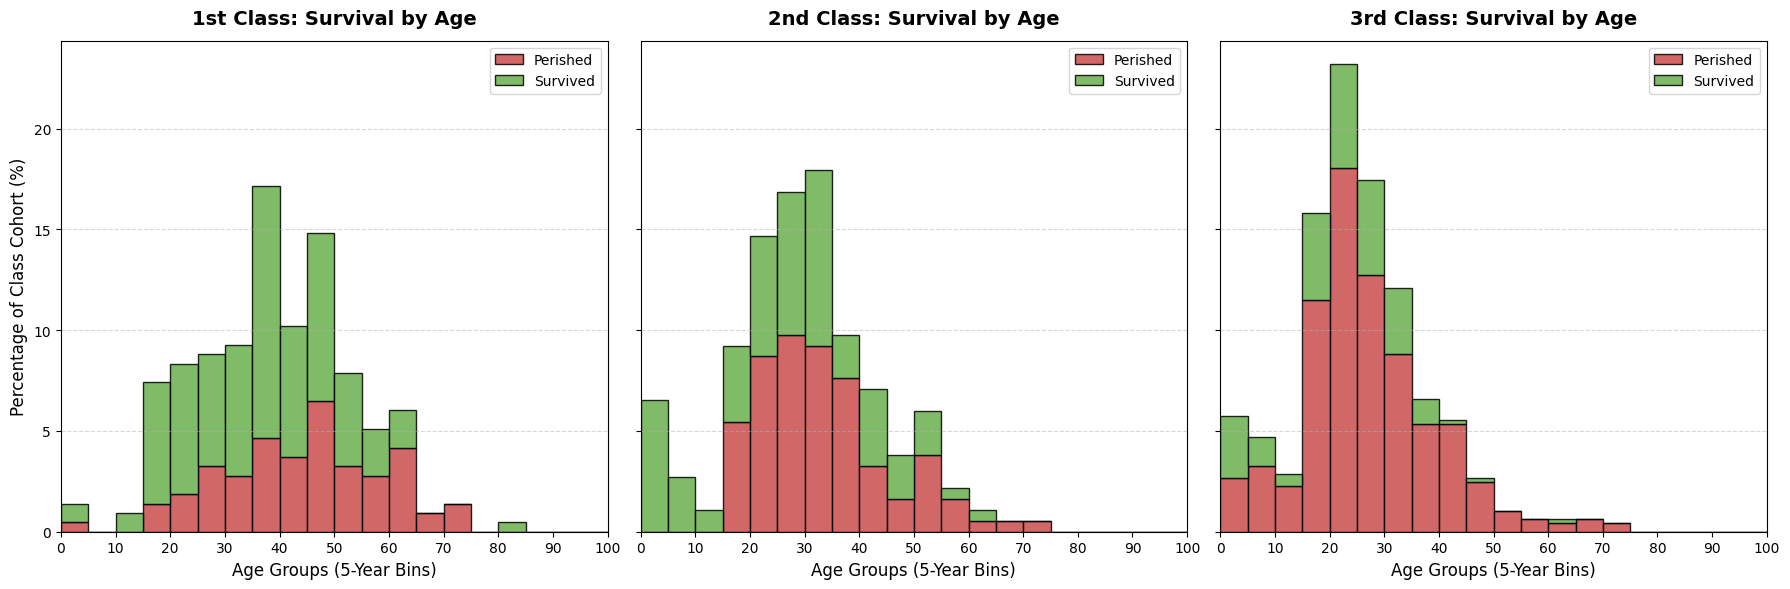

In [11]:
df['ticket_class'] = np.where(df['1st_class'] == 1, 1, 
                       np.where(df['2nd_class'] == 1, 2, 3))

# 2. Establish the precise 20-bin geometry between 0 and 100 years
bins = np.linspace(0, 100, 21)

# 3. Initialize the multi-panel shared Y-axis canvas (3 columns this time)
fig, ax = plt.subplots(ncols=3, figsize=(18, 6), sharey=True)

# Define thematic colors and labels
colors = ['#c94c4c', '#6ab04c'] # Red (Perished), Green (Survived)
labels = ['Perished', 'Survived']
class_names = {1: '1st Class', 2: '2nd Class', 3: '3rd Class'}

# 4. Iterate through each of the 3 classes and draw the corresponding paper (ax[0], ax[1], ax[2])
for i, pclass in enumerate([1, 2, 3]):
    # Isolate the specific class DataFrame
    class_df = df[df['ticket_class'] == pclass]
    
    # Split by survival
    died_ages = class_df[class_df['survived'] == 0]['age']
    surv_ages = class_df[class_df['survived'] == 1]['age']
    
    # Calculate relative weights so Y-axis equals 100% of THIS specific class
    w_died = np.ones_like(died_ages) * 100.0 / len(class_df)
    w_surv = np.ones_like(surv_ages) * 100.0 / len(class_df)
    
    # Draw the stacked histogram on the current piece of paper
    ax[i].hist([died_ages, surv_ages], bins=bins, weights=[w_died, w_surv],
               stacked=True, color=colors, edgecolor='black', alpha=0.85, label=labels)
    
    # Format the specific panel
    ax[i].set_title(f"{class_names[pclass]}: Survival by Age", fontsize=14, fontweight='bold', pad=12)
    ax[i].set_xlabel("Age Groups (5-Year Bins)", fontsize=12)
    ax[i].set_xlim(0, 100)
    ax[i].set_xticks(np.arange(0, 101, 10))
    ax[i].legend(loc='upper right')
    ax[i].grid(axis='y', linestyle='--', alpha=0.5)

# Set the Y-axis label only on the far-left graph
ax[0].set_ylabel("Percentage of Class Cohort (%)", fontsize=12)

# Optimize spatial geometry to prevent edge truncation
plt.tight_layout()

# Export the high-fidelity visualization artifact directly to storage
fig.savefig("class_age_survival_distribution.png", dpi=300)
print("=== Class & Age Multivariate Demographics Exported Successfully ===")

### 2.7 Survival Stratification by Family Size
To evaluate how family structures influenced survivability, the passenger cohort is stratified by total `family_size` (ranging from $0$, indicating solo travelers, to a maximum of $10$ accompanying relatives).

The resulting visualization normalizes the absolute counts into relative percentages for the Male and Female cohorts. This reveals distinct behavioral survivability patterns, specifically testing the hypothesis of whether traveling with a mid-sized family provided a collaborative survival advantage compared to traveling alone or with a massive family unit.

=== Family Size Demographics Rendered and Exported Successfully ===


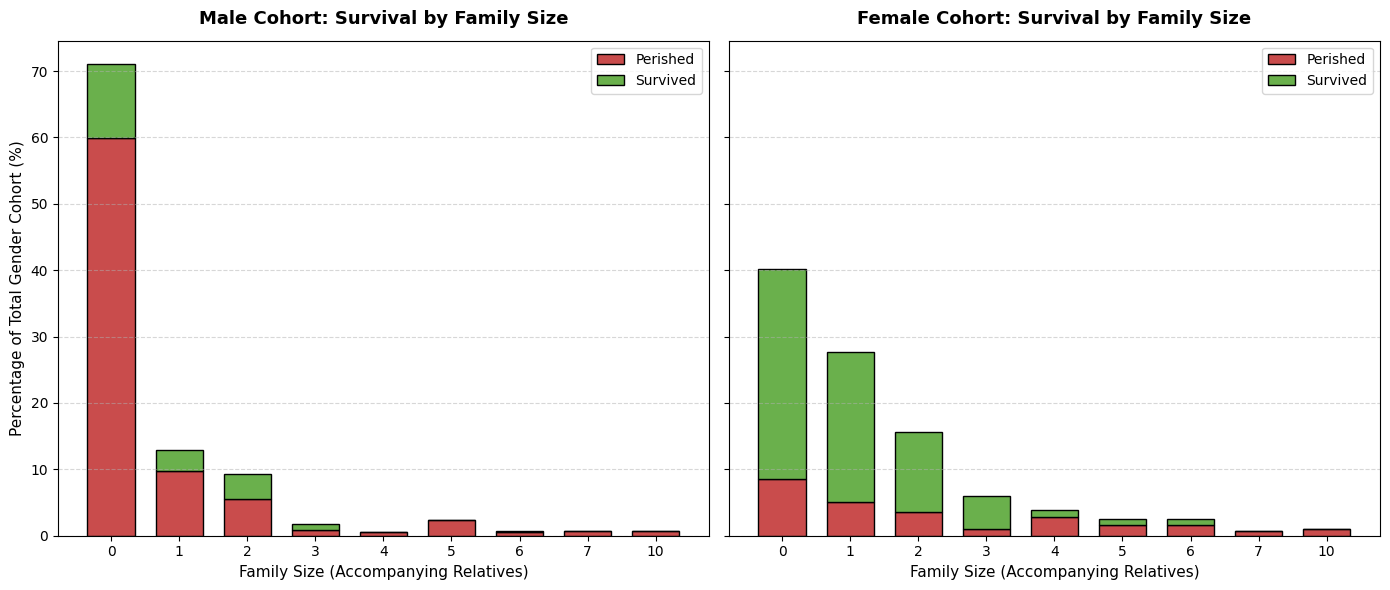

In [12]:
all_family_sizes = sorted(df['family_size'].unique())

def calculate_family_percentages(gender_df, all_sizes):
    """
    Groups the dataframe by family size and survival, counts the individuals, 
    converts them into a percentage relative to the total gender population,
    and aligns the index to guarantee all sizes (0-10) are plotted.
    """
    total_population = len(gender_df)
    
    # Create matrix of counts: rows = family_size, columns = survived (0 or 1)
    counts = gender_df.groupby(['family_size', 'survived']).size().unstack(fill_value=0)
    
    # Convert absolute counts to percentages
    percentage_matrix = (counts / total_population) * 100
    
    # Reindex ensures that even if a gender has 0 people of a specific family size, 
    # it still exists in the math array to prevent graph misalignment
    return percentage_matrix.reindex(all_sizes, fill_value=0)

# Process the statistics for both genders
male_stats = calculate_family_percentages(male_df, all_family_sizes)
female_stats = calculate_family_percentages(female_df, all_family_sizes)

# Initialize the multi-panel shared Y-axis canvas
fig, ax = plt.subplots(ncols=2, figsize=(14, 6), sharey=True)

# Plot definitions
x_positions = np.arange(len(all_family_sizes))
bar_width = 0.7
colors = ['#c94c4c', '#6ab04c'] # Red (0: Perished), Green (1: Survived)

# --- Panel 1: Male Kinship Matrix ---
ax[0].bar(x_positions, male_stats[0], bar_width, color=colors[0], edgecolor='black', label='Perished')
ax[0].bar(x_positions, male_stats[1], bar_width, bottom=male_stats[0], color=colors[1], edgecolor='black', label='Survived')
ax[0].set_xticks(x_positions)
ax[0].set_xticklabels(all_family_sizes)
ax[0].set_title("Male Cohort: Survival by Family Size", fontsize=13, fontweight='bold', pad=12)
ax[0].set_xlabel("Family Size (Accompanying Relatives)", fontsize=11)
ax[0].set_ylabel("Percentage of Total Gender Cohort (%)", fontsize=11)
ax[0].legend(loc='upper right')
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Panel 2: Female Kinship Matrix ---
ax[1].bar(x_positions, female_stats[0], bar_width, color=colors[0], edgecolor='black', label='Perished')
ax[1].bar(x_positions, female_stats[1], bar_width, bottom=female_stats[0], color=colors[1], edgecolor='black', label='Survived')
ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(all_family_sizes)
ax[1].set_title("Female Cohort: Survival by Family Size", fontsize=13, fontweight='bold', pad=12)
ax[1].set_xlabel("Family Size (Accompanying Relatives)", fontsize=11)
ax[1].legend(loc='upper right')
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

# Optimize spatial geometry to prevent edge truncation
plt.tight_layout()

# Export the high-fidelity visualization artifact directly to storage
fig.savefig("family_size_survival_distribution.png", dpi=300)
print("=== Family Size Demographics Rendered and Exported Successfully ===")

### 2.8 Capital Matrix: Survival Stratification by Ticket Fare

To decompose the financial privilege matrix, we evaluate the raw `fare` (ticket price) paid by each passenger. 

Because ticket prices exhibit extreme right-skewness (with outliers exceeding $500), the visualization programmatically clips the maximum threshold at $150. Any values exceeding this threshold are aggregated into the final distribution bin. The financial spectrum is segmented into $10 increments and split by gender, revealing the direct correlation between absolute capital and survival priority.

=== Fare Structure Demographics Rendered and Exported Successfully ===


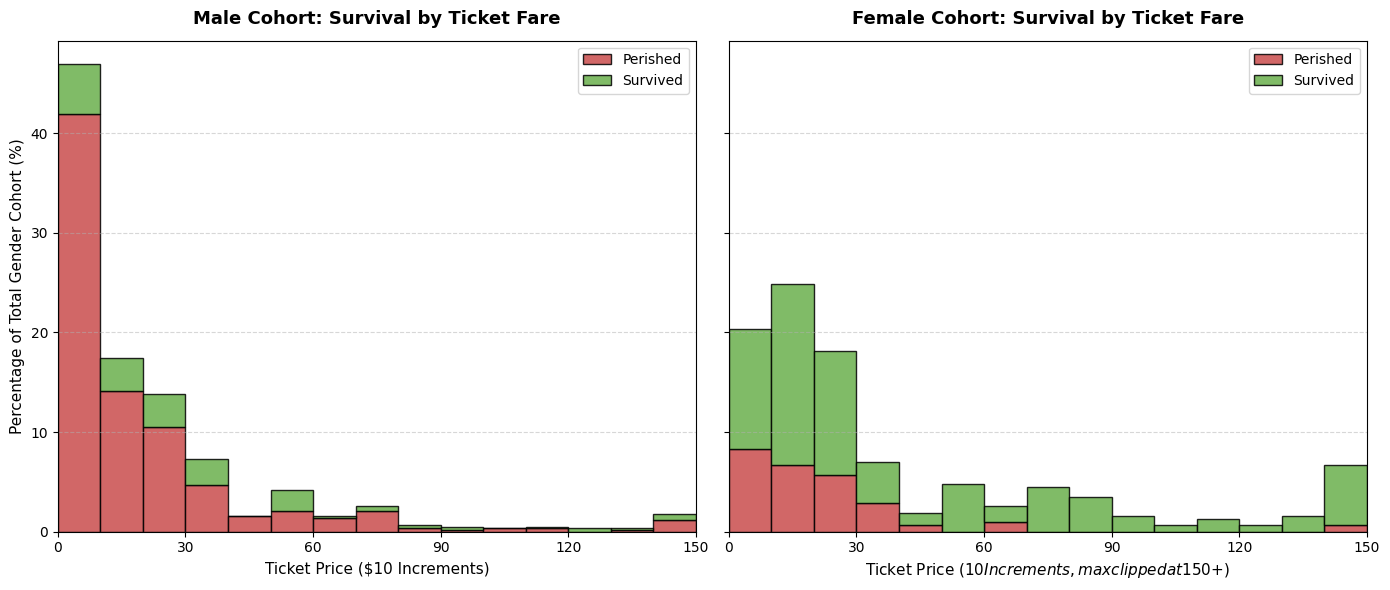

In [13]:
df['fare_clipped'] = df['fare'].clip(upper=150)

#  Establish 15 bins from 0 to 150 (each bin represents exactly $10)
bins = np.linspace(0, 150, 16)

# Isolate the gender DataFrames
male_df = df[df['sex'] == 1]
female_df = df[df['sex'] == 0]

# Split each gender into Survived (1) and Perished (0) fare arrays
male_died = male_df[male_df['survived'] == 0]['fare_clipped']
male_survived = male_df[male_df['survived'] == 1]['fare_clipped']

female_died = female_df[female_df['survived'] == 0]['fare_clipped']
female_survived = female_df[female_df['survived'] == 1]['fare_clipped']

# Compute weight vectors relative to the TOTAL gender population
mw_died = np.ones_like(male_died) * 100.0 / len(male_df)
mw_surv = np.ones_like(male_survived) * 100.0 / len(male_df)

fw_died = np.ones_like(female_died) * 100.0 / len(female_df)
fw_surv = np.ones_like(female_survived) * 100.0 / len(female_df)

# Initialize the multi-panel shared Y-axis canvas
fig, ax = plt.subplots(ncols=2, figsize=(14, 6), sharey=True)

# Define thematic colors and labels
colors = ['#c94c4c', '#6ab04c']
labels = ['Perished', 'Survived']

# --- Panel 1: Male Fare Stratification ---
ax[0].hist([male_died, male_survived], bins=bins, weights=[mw_died, mw_surv], 
           stacked=True, color=colors, edgecolor='black', alpha=0.85, label=labels)
ax[0].set_title("Male Cohort: Survival by Ticket Fare", fontsize=13, fontweight='bold', pad=12)
ax[0].set_xlabel("Ticket Price ($10 Increments)", fontsize=11)
ax[0].set_ylabel("Percentage of Total Gender Cohort (%)", fontsize=11)
ax[0].set_xlim(0, 150)
ax[0].set_xticks(np.arange(0, 151, 30))
ax[0].legend(loc='upper right')
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Panel 2: Female Fare Stratification ---
ax[1].hist([female_died, female_survived], bins=bins, weights=[fw_died, fw_surv], 
           stacked=True, color=colors, edgecolor='black', alpha=0.85, label=labels)
ax[1].set_title("Female Cohort: Survival by Ticket Fare", fontsize=13, fontweight='bold', pad=12)
ax[1].set_xlabel("Ticket Price ($10 Increments, max clipped at $150+)", fontsize=11)
ax[1].set_xlim(0, 150)
ax[1].set_xticks(np.arange(0, 151, 30))
ax[1].legend(loc='upper right')
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

# Optimize spatial geometry to prevent edge truncation
plt.tight_layout()

# Export the high-fidelity visualization artifact directly to storage
fig.savefig("fare_survival_distribution.png", dpi=300)
print("=== Fare Structure Demographics Rendered and Exported Successfully ===")

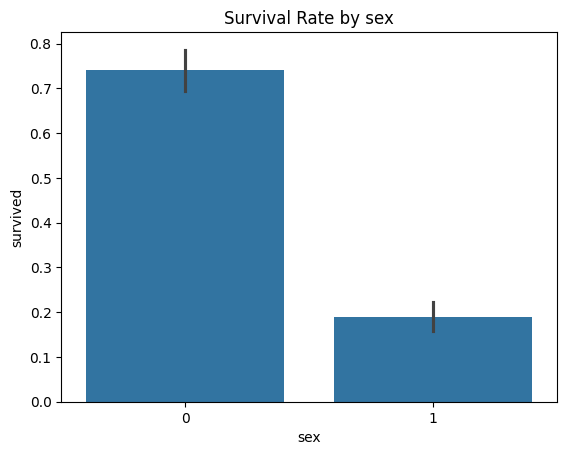

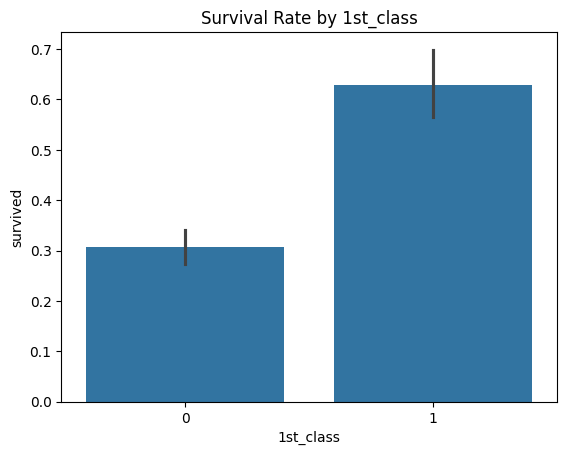

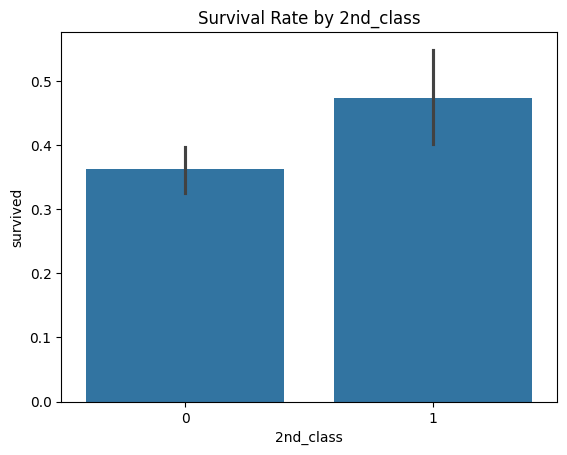

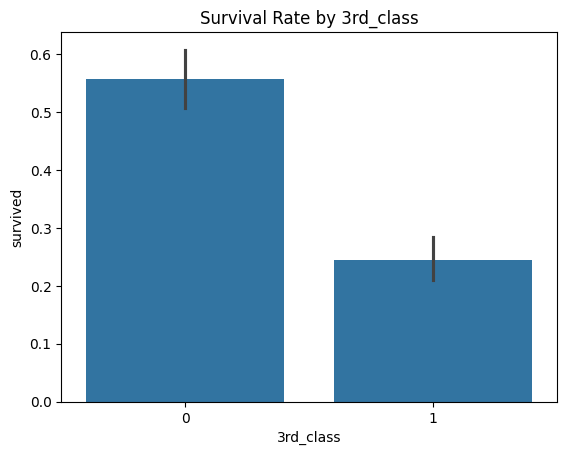

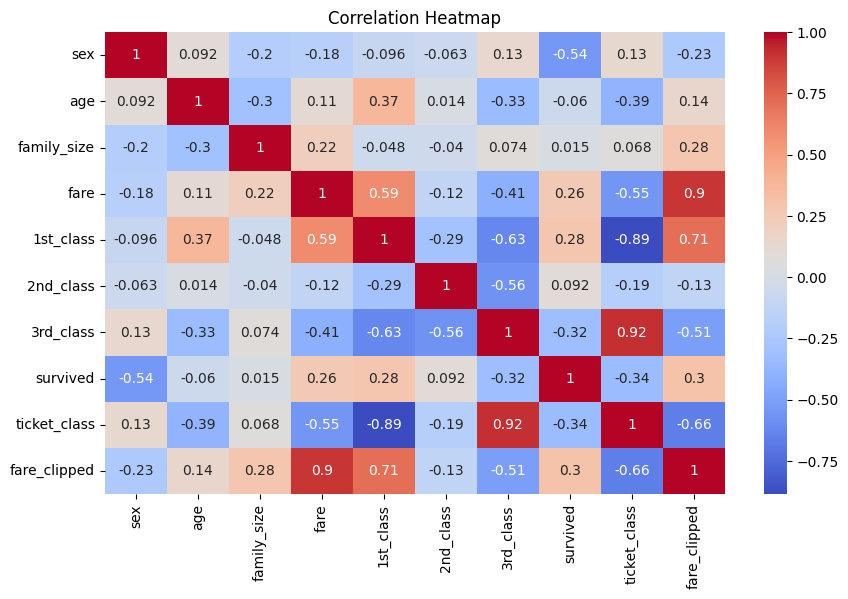

In [30]:
import seaborn as sns

numeric_features = ["age", "family_size", "fare"]
binary_features = ["sex", "1st_class", "2nd_class", "3rd_class"]

for features in df.columns:
    if features in binary_features:
        sns.barplot(x=features, y='survived', data=df)
        plt.title('Survival Rate by {features}'.format(features=features))
        plt.show()

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

---

Phase 2: Feature Engineering & State Preservation Scaling

Before exposing the data to the Logistic Regression algorithm, the raw feature matrix must be scaled. Features like `fare` span from 0 to over 500, while `age` spans from 0 to 80, and `sex` is strictly binary (0 or 1). Unscaled continuous variables can exert disproportionate gravitational pull on the algorithm's gradient descent optimizer.

To prevent **Data Leakage**, the statistical parameters (Mean and Standard Deviation) are calculated strictly on the Training Set. The Scaler algorithm locks these parameters into memory and applies them to both the Training Set and the unseen Test Set, ensuring absolute state preservation.

In [28]:
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['survived'])
y = df['survived']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) 
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


**random_state** variable makes the set reproducable, so that each time same rows are selected for training and testing purposes

In [16]:
print(X_train.describe())

              sex         age  family_size        fare   1st_class  \
count  709.000000  709.000000   709.000000  709.000000  709.000000   
mean     0.631876   29.326643     0.923836   33.547302    0.239774   
std      0.482636   14.100166     1.668877   52.912893    0.427247   
min      0.000000    0.670000     0.000000    0.000000    0.000000   
25%      0.000000   20.500000     0.000000    7.895800    0.000000   
50%      1.000000   28.000000     0.000000   14.458300    0.000000   
75%      1.000000   37.000000     1.000000   31.275000    0.000000   
max      1.000000   80.000000    10.000000  512.329200    1.000000   

        2nd_class   3rd_class  ticket_class  fare_clipped  
count  709.000000  709.000000    709.000000    709.000000  
mean     0.204513    0.555712      2.315938     30.053579  
std      0.403630    0.497237      0.834657     35.109469  
min      0.000000    0.000000      1.000000      0.000000  
25%      0.000000    0.000000      2.000000      7.895800  
50%      

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(y_pred[:10])

[0 0 0 0 0 1 0 0 1 1]


/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:

In [21]:
y_proba = model.predict_proba(X_test)
print(y_proba) 

[[9.99999973e-01 2.73463019e-08]
 [9.93561990e-01 6.43800971e-03]
 [1.00000000e+00 1.04134766e-15]
 [9.99999999e-01 1.13766375e-09]
 [1.00000000e+00 5.47137231e-13]
 [9.98312616e-01 1.68738370e-03]
 [9.99983148e-01 1.68523417e-05]
 [9.99995213e-01 4.78721724e-06]
 [9.99999195e-01 8.04690311e-07]
 [9.99962371e-01 3.76285742e-05]
 [9.99993090e-01 6.90976762e-06]
 [9.99990394e-01 9.60575908e-06]
 [9.99998573e-01 1.42710690e-06]
 [1.00000000e+00 4.61027324e-13]
 [9.99997671e-01 2.32937555e-06]
 [9.99999993e-01 6.72402507e-09]
 [1.00000000e+00 1.52950618e-12]
 [1.66439447e-07 9.99999834e-01]
 [9.99996787e-01 3.21284873e-06]
 [9.99959022e-01 4.09784760e-05]
 [9.99986852e-01 1.31481637e-05]
 [9.60992612e-01 3.90073879e-02]
 [9.99991388e-01 8.61193120e-06]
 [9.99990340e-01 9.65973458e-06]
 [5.94132356e-01 4.05867644e-01]
 [9.99999554e-01 4.45931038e-07]
 [1.00000000e+00 1.97433529e-10]
 [9.99999541e-01 4.58651940e-07]
 [9.99998642e-01 1.35757368e-06]
 [9.98047446e-01 1.95255412e-03]
 [9.967214

/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


---

### Phase 3 Model Evaludation

---

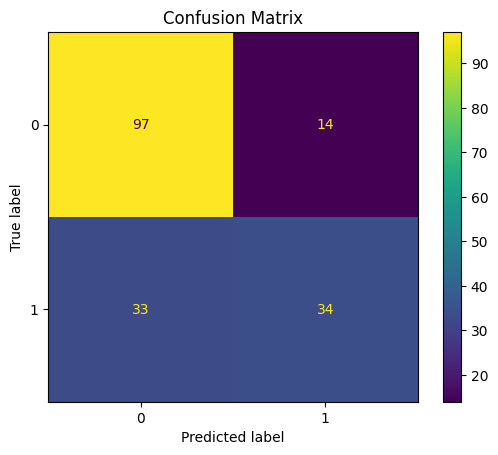

[[97 14]
 [33 34]]


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()
print (cm)

### 3.1 Model Performance: Confusion Matrix & Classification Report

To evaluate the structural performance of the unscaled Logistic Regression model, we analyze its predictions against the actual ground truth using a Confusion Matrix. 

The matrix results (`[[97, 14], [33, 34]]`) reveal a stark contrast in predictive capability between the two target states:
* **Perished (Class 0):** The model performs highly reliably here. It correctly identified **97** perished individuals, demonstrating a strong detection rate (recall) of 87% for this class.
* **Survived (Class 1):** The situation with the survivors is not nearly as good. The model correctly identified only **34** survivors, while completely missing **33** actual survivors (predicting them as perished instead).

### 3.2 Conclusion

This results in a low detection rate of just 51% for the surviving class. This severe imbalance indicates that the model is heavily skewed toward predicting casualties, likely because the unscaled continuous features (like extreme ticket fares) are confusing the linear algorithm's weights.